# Aurèle GALLARD RL Assignement Notebook

# Reinforcement Learning Assignment: Text Flappy Bird

This notebook implements and compares two Reinforcement Learning agents (Monte Carlo and Sarsa($\lambda$)) on the Text Flappy Bird environment.

## Part 1: Environment Setup and Custom State Extraction

The standard `TextFlappyBird-screen-v0` environment returns a full 2D grid representing the screen. To make tabular RL algorithms feasible while retaining a rich understanding of the game dynamics, we implement a custom `ObservationWrapper`. 

This wrapper extracts a more complex state from the screen pixels:
1. `dx1`, `dy1`: Horizontal and vertical distance to the first upcoming pipe gap.
2. `v_y`: The vertical velocity of the bird.
3. `dy2`: The vertical distance to the *second* upcoming pipe gap (returns `None` if not visible on screen).

In [24]:
# Installation de l'environnement (à décommenter si besoin)
!pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git

  Cloning https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to c:\users\user\appdata\local\temp\pip-req-build-i6hohq8b
  Resolved https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to commit ca2797e9270195313423324c9d0f205f6cbb3d28
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git 'C:\Users\user\AppData\Local\Temp\pip-req-build-i6hohq8b'

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import os
import sys
import gymnasium as gym
import text_flappy_bird_gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class FlappyFeatureExtractor(gym.ObservationWrapper):
    """
    A custom wrapper that extracts meaningful features from the raw screen array.
    """
    def __init__(self, env):
        super().__init__(env)
        self.prev_bird_y = None
        self.last_raw_obs = None # Stored for visualization purposes
        
    def observation(self, obs):
        self.last_raw_obs = obs.copy()
        
        # 1. Find bird position
        bird_coords = np.where(obs == 1)
        if len(bird_coords[0]) == 0:
            return (0, 0, 0, None)
            
        bird_x, bird_y = bird_coords[0][0], bird_coords[1][0]
        
        # Calculate vertical velocity
        v_y = 0
        if self.prev_bird_y is not None:
            v_y = bird_y - self.prev_bird_y
        self.prev_bird_y = bird_y
        
        # 2. Find upcoming pipes
        pipe_coords = np.where(obs == 2)
        pipe_x_unique = np.unique(pipe_coords[0])
        upcoming_pipes_x = np.sort(pipe_x_unique[pipe_x_unique > bird_x])
        
        dx1, dy1, dy2 = 0, 0, None # dy2 defaults to None if not visible
        
        if len(upcoming_pipes_x) > 0:
            # First pipe
            pipe1_x = upcoming_pipes_x[0]
            pipe1_y_coords = pipe_coords[1][pipe_coords[0] == pipe1_x]
            full_column = set(range(self.env.unwrapped._screen_size[1]))
            gap1_y_coords = list(full_column - set(pipe1_y_coords))
            
            if gap1_y_coords:
                gap1_center = int(np.mean(gap1_y_coords))
                dx1 = pipe1_x - bird_x
                dy1 = bird_y - gap1_center
                
            # Second pipe
            if len(upcoming_pipes_x) > 1:
                pipe2_x = upcoming_pipes_x[1]
                pipe2_y_coords = pipe_coords[1][pipe_coords[0] == pipe2_x]
                gap2_y_coords = list(full_column - set(pipe2_y_coords))
                
                if gap2_y_coords:
                    gap2_center = int(np.mean(gap2_y_coords))
                    dy2 = bird_y - gap2_center
                    
        return (dx1, dy1, v_y, dy2)

    def reset(self, **kwargs):
        self.prev_bird_y = None
        obs, info = self.env.reset(**kwargs)
        return self.observation(obs), info

Running simulation and plotting...


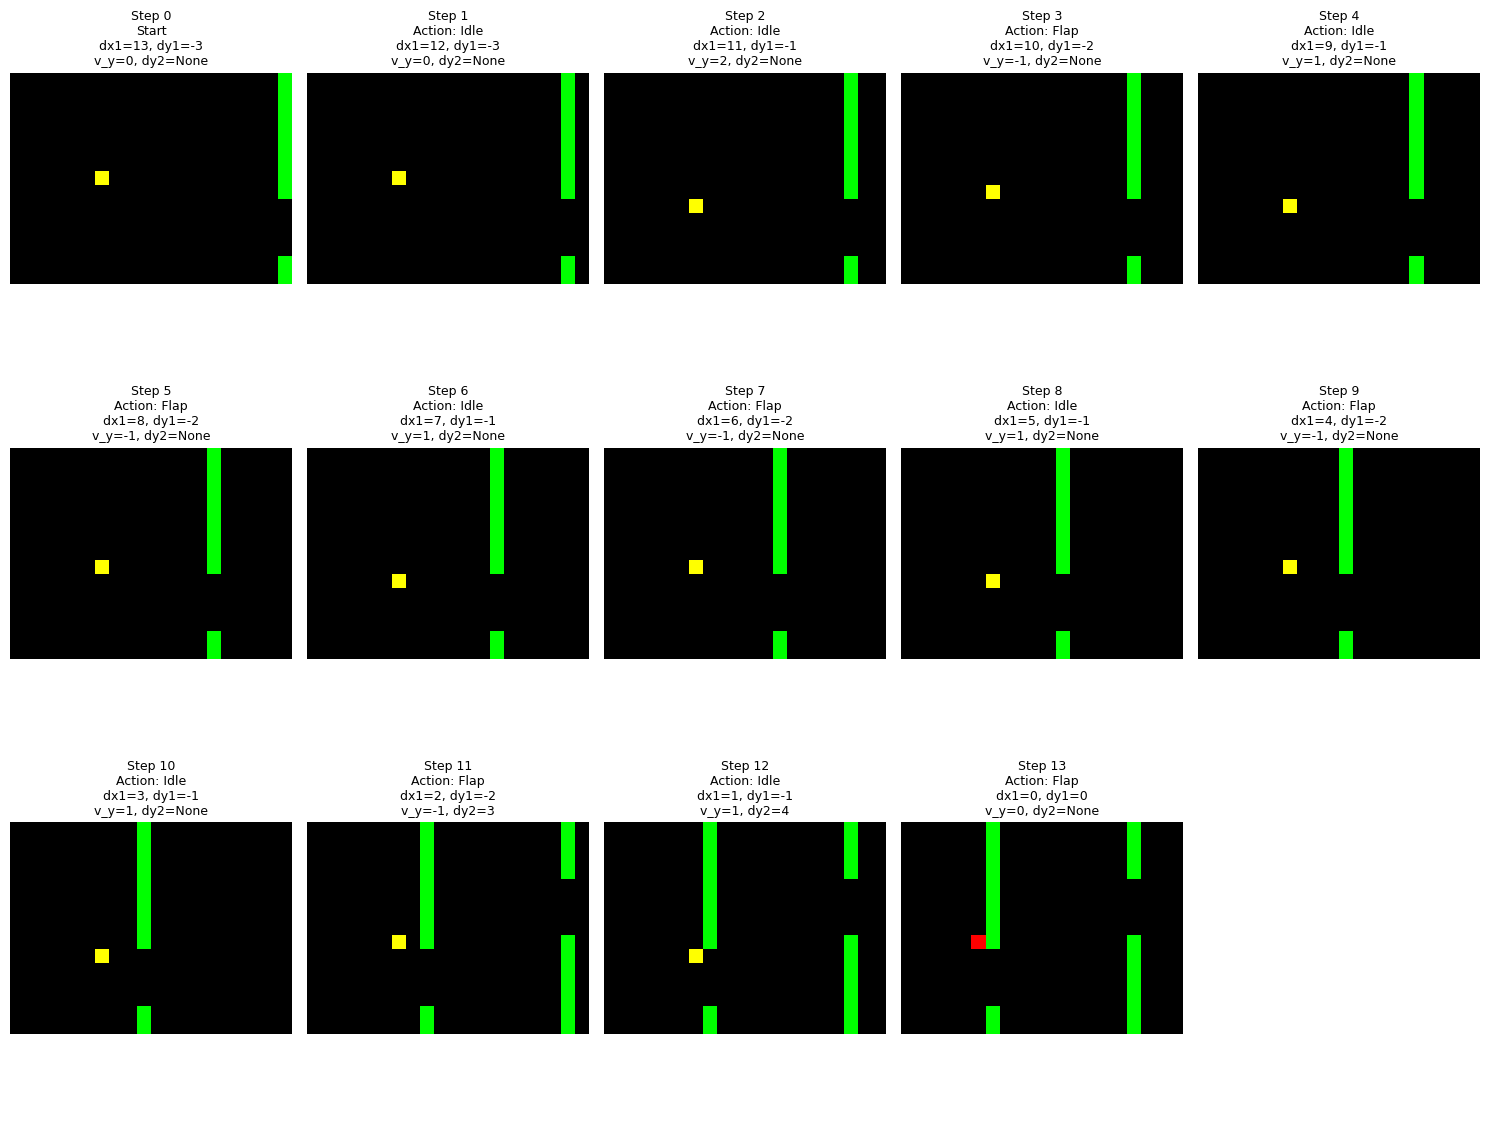

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.colors import ListedColormap

def plot_game_state(env, actions=[0, 1, 0, 0], max_cols=5):
    """
    Joue quelques étapes et affiche l'écran de manière optimisée sur plusieurs lignes.
    """
    # Configuration des couleurs
    colors = ['#000000', '#FFFF00', '#00FF00', '#FF0000', '#FFFFFF', '#FFFFFF', '#87CEEB', '#8B4513']
    cmap = ListedColormap(colors)
    
    # Calcul de la structure de la grille (1 état initial + n actions)
    total_plots = len(actions) + 1
    n_cols = min(total_plots, max_cols)
    n_rows = math.ceil(total_plots / n_cols)
    
    # Création de la figure avec une taille dynamique
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 4))
    
    # Aplatir les axes pour une itération facile (gère le cas 1x1 ou n x m)
    axes_flat = axes.flatten() if total_plots > 1 else [axes]
    
    def draw_step(ax, raw_obs, custom_obs, step_num, action=None):
        # Transformation de la matrice pour le rendu visuel
        render_matrix = np.flipud(np.rot90(raw_obs, 1))
        ax.imshow(render_matrix, cmap=cmap, vmin=0, vmax=7)
        
        act_str = f"Action: {'Flap' if action==1 else 'Idle'}\n" if action is not None else "Start\n"
        title = f"Step {step_num}\n{act_str}"
        title += f"dx1={custom_obs[0]}, dy1={custom_obs[1]}\n"
        title += f"v_y={custom_obs[2]}, dy2={custom_obs[3]}"
        
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    # État initial
    obs, _ = env.reset()
    draw_step(axes_flat[0], env.last_raw_obs, obs, 0)
    
    # Simulation des étapes
    current_step = 0
    for i, action in enumerate(actions):
        current_step = i + 1
        obs, reward, done, _, _ = env.step(action)
        
        draw_step(axes_flat[current_step], env.last_raw_obs, obs, current_step, action)
        
        if done:
            break

    # Cacher les subplots vides si le dernier rang n'est pas complet
    for j in range(current_step + 1, len(axes_flat)):
        axes_flat[j].axis('off')
            
    plt.tight_layout()
    plt.show()

# --- Test de l'environnement ---
base_env = gym.make('TextFlappyBird-screen-v0', height=15, width=20, pipe_gap=4)
env_custom = FlappyFeatureExtractor(base_env)

print("Running simulation and plotting...")
# Exemple avec 13 actions, s'affichera sur 3 lignes (si max_cols=5)
plot_game_state(env_custom, actions=[0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1], max_cols=5)
env_custom.close()

## Part 2: Monte Carlo First-Visit On-Policy Agent

In this section, we implement a First-Visit Monte Carlo control algorithm using an $\epsilon$-greedy policy. 

Since we are using our custom feature extractor, our state space is defined as the tuple `(dx1, dy1, v_y, dy2)`. While this representation provides a deeper understanding of the game dynamics, it significantly increases the size of the state space compared to the simple environment. Consequently, the agent will require more episodes to converge.

We will estimate the action-value function $Q(s, a)$ and then derive the state-value function $V(s) = \max_{a} Q(s, a)$.

In [27]:
from collections import defaultdict
from tqdm import tqdm

def generate_episode(env, Q, epsilon):
    """Generates an episode using an epsilon-greedy policy."""
    episode = []
    state, _ = env.reset()
    done = False
    
    while not done:
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
            
        next_state, reward, done, _, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        
    return episode

def train_monte_carlo(env, num_episodes, gamma=1.0, epsilon=0.1):
    """Trains a First-Visit Monte Carlo agent."""
    # Initialize Q-table with zeros. 
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)
    scores = []
    
    # We wrap the range() with tqdm() to automatically generate the progress bar
    for i in tqdm(range(1, num_episodes + 1), desc="Training MC Agent"):
        episode = generate_episode(env, Q, epsilon)
        
        # In this environment, reward is 1 per step alive. 
        score = sum([step[2] for step in episode])
        scores.append(score)
        
        G = 0
        visited_sa = set()
        
        # Traverse the episode backwards to calculate returns
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            sa_pair = (state, action)
            
            # First-visit check
            if sa_pair not in visited_sa:
                visited_sa.add(sa_pair)
                returns_sum[sa_pair] += G
                returns_count[sa_pair] += 1.0
                # Update Q-value incrementally
                Q[state][action] = returns_sum[sa_pair] / returns_count[sa_pair]
                
    return Q, scores

# Initialize the custom environment
base_env = gym.make('TextFlappyBird-screen-v0', height=15, width=20, pipe_gap=4)
env_custom = FlappyFeatureExtractor(base_env)

# Training parameters
num_episodes_mc = 50000 
gamma_mc = 1.0
epsilon_mc = 0.1

print("Starting Monte Carlo training on custom environment...")
mc_Q, mc_scores = train_monte_carlo(env_custom, num_episodes_mc, gamma_mc, epsilon_mc)
print("Monte Carlo training completed!")

Starting Monte Carlo training on custom environment...


Training MC Agent: 100%|██████████| 50000/50000 [24:06<00:00, 34.57it/s]

Monte Carlo training completed!


### Visualizing the State-Value Function $V(s)$

Because our state space is 4-dimensional `(dx1, dy1, v_y, dy2)`, we cannot plot it entirely on a 2D surface. To visualize $V(s)$, we will extract a "slice" of the state space. 

We will fix the bird's vertical velocity `v_y = -1` (ie when we just hit flap) and assume the second pipe is not yet visible (`dy2 = None`). This allows us to plot the expected returns as a function of the distance to the *first* pipe `(dx1, dy1)`.

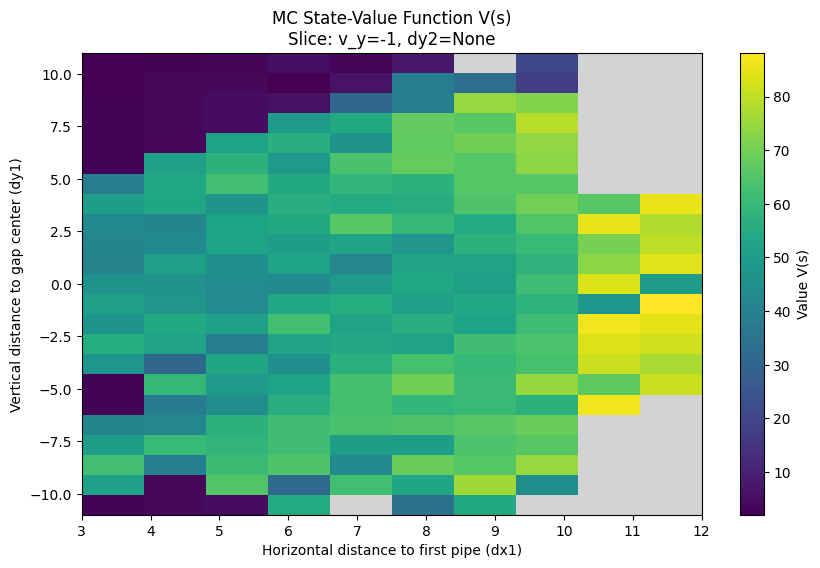

In [28]:
def plot_state_value_slice(Q, fixed_v_y=-1, fixed_dy2=None, title="State-Value Function V(s)"):
    """
    Plots a 2D slice of the V(s) function by fixing v_y and dy2.
    """
    states = list(Q.keys())
    if not states:
        print("Q-table is empty.")
        return
        
    # Filter states that match our slice criteria
    # State format: (dx1, dy1, v_y, dy2)
    slice_states = [s for s in states if s[2] == fixed_v_y and s[3] == fixed_dy2]
    
    if not slice_states:
        print(f"No states found for v_y={fixed_v_y} and dy2={fixed_dy2}. Try different fixed values.")
        return

    x_vals = [s[0] for s in slice_states]
    y_vals = [s[1] for s in slice_states]
    
    x_min, x_max = min(x_vals), max(x_vals)
    y_min, y_max = min(y_vals), max(y_vals)
    
    # Create a grid initialized to NaN to represent unvisited states
    V = np.full((y_max - y_min + 1, x_max - x_min + 1), np.nan)
    
    for s in slice_states:
        x, y = s[0], s[1]
        # V(s) = max_a Q(s, a)
        V[y - y_min, x - x_min] = np.max(Q[s])
        
    plt.figure(figsize=(10, 6))
    
    # We use a colormap that handles NaNs (unvisited states) gracefully
    cmap = plt.cm.viridis
    cmap.set_bad(color='lightgray')
    
    plt.imshow(V, cmap=cmap, origin='lower', extent=[x_min, x_max, y_min, y_max], aspect='auto')
    plt.colorbar(label='Value V(s)')
    plt.xlabel('Horizontal distance to first pipe (dx1)')
    plt.ylabel('Vertical distance to gap center (dy1)')
    plt.title(f"{title}\nSlice: v_y={fixed_v_y}, dy2={fixed_dy2}")
    
    # Grid adjustments
    plt.grid(False)
    plt.show()

# Plot the state-value function slice for Monte Carlo
plot_state_value_slice(mc_Q, fixed_v_y=-1, fixed_dy2=None, title="MC State-Value Function V(s)")

### Evaluating the Trained Monte Carlo Agent

Now that our agent is trained, let's watch it play an episode! 
To evaluate its true performance, we disable exploration ($\epsilon = 0$) and make it act purely greedily according to the learned Q-table: `action = argmax(Q(s))`.

In [29]:
import time
from IPython.display import clear_output
import sys

def watch_agent_play(env, Q, fps=5):
    """
    Runs one episode using the trained Q-table greedily and renders it in the notebook.
    """
    state, info = env.reset()
    done = False
    total_reward = 0
    step_count = 0
    
    while not done:
        # Purely greedy policy (Exploitation only)
        # If the state was never visited, Q[state] is [0, 0], so it defaults to action 0 (Idle)
        action = np.argmax(Q[state])
        
        state, reward, done, _, info = env.step(action)
        total_reward += reward
        step_count += 1
        
        # Render the game
        clear_output(wait=True)
        
        # The base environment's render method returns a string
        # We use env.unwrapped to safely access the base text rendering
        game_screen = env.unwrapped.render()
        print(game_screen)
        
        # Print additional info below the screen
        print(f"Step: {step_count} | Action taken: {'Flap' if action == 1 else 'Idle'}")
        print(f"Current State: (dx1={state[0]}, dy1={state[1]}, v_y={state[2]}, dy2={state[3]})")
        
        time.sleep(1.0 / fps)

        if step_count >= 1000:  # Safety check to prevent infinite loops
            print("Reached step limit, ending episode.")
            break
        
    print(f"\nGame Over! Total Score/Steps: {total_reward}")

watch_agent_play(env_custom, mc_Q, fps=10)

Text Flappy Bird!
Score: 99
----------------------
[         |          ]
[         |          ]
[                    ]
[      @             ]
[                    ]
[                    ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
^^^^^^^^^^^^^^^^^^^^^^
(Flap)

Step: 1000 | Action taken: Flap
Current State: (dx1=3, dy1=0, v_y=-1, dy2=None)
Reached step limit, ending episode.

Game Over! Total Score/Steps: 1000


## Part 3: Sarsa($\lambda$) Agent with Eligibility Traces

In this section, we implement the Sarsa($\lambda$) algorithm as described in Chapter 12.7 of the Reinforcement Learning book by Sutton & Barto. 

Unlike Monte Carlo, which waits until the end of an episode to update the Q-values, Sarsa is a Temporal Difference (TD) learning method that updates step-by-step. The $\lambda$ parameter introduces **Eligibility Traces**, creating a bridge between TD(0) and Monte Carlo methods. When a reward is received, it is propagated backward to recently visited states, which significantly speeds up learning in environments with sparse or delayed rewards.

**Optimization Note:** To prevent the algorithm from slowing down drastically, we optimize the trace updates by only iterating over "active" traces (where $E(s, a) > 0.01$) rather than the entire state-action space. We also use *replacing traces* ($E(s, a) = 1$) instead of accumulating traces to maintain stability.

In [30]:
def train_sarsa_lambda(env, num_episodes, alpha=0.1, gamma=1.0, epsilon=0.1, lambd=0.9):
    """Trains an agent using the Sarsa(lambda) algorithm."""
    # Initialize Q-table
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    scores = []

    for i in tqdm(range(1, num_episodes + 1), desc="Training Sarsa(λ) Agent"):
        state, _ = env.reset()
        
        # Initial action selection (Epsilon-greedy)
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        # Initialize Eligibility Traces for this episode
        E = defaultdict(float)
        score = 0
        done = False

        while not done:
            next_state, reward, done, _, _ = env.step(action)
            score += reward

            # Next action selection (Epsilon-greedy)
            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(Q[next_state])

            # Calculate TD Error (delta)
            if done:
                delta = reward - Q[state][action]
            else:
                delta = reward + gamma * Q[next_state][next_action] - Q[state][action]

            # Update Eligibility Trace (Replacing trace)
            E[(state, action)] = 1.0

            # Update Q-values and decay traces, strictly for active traces to optimize speed
            active_traces = list(E.keys())
            for sa_pair in active_traces:
                s, a = sa_pair
                Q[s][a] += alpha * delta * E[sa_pair]
                E[sa_pair] *= gamma * lambd
                
                # Prune very small traces to maintain execution speed
                if E[sa_pair] < 0.01:
                    del E[sa_pair]

            state = next_state
            action = next_action

        scores.append(score)
        
    return Q, scores

# Training parameters
num_episodes_sarsa = 50000
alpha_sarsa = 0.1
gamma_sarsa = 1.0
epsilon_sarsa = 0.1
lambda_param = 0.9

print("Starting Sarsa(λ) training on custom environment...")
sarsa_Q, sarsa_scores = train_sarsa_lambda(
    env_custom, 
    num_episodes_sarsa, 
    alpha_sarsa, 
    gamma_sarsa, 
    epsilon_sarsa, 
    lambda_param
)
print("Sarsa(λ) training completed!")

Starting Sarsa(λ) training on custom environment...


Training Sarsa(λ) Agent: 100%|██████████| 50000/50000 [22:05<00:00, 37.72it/s] 

Sarsa(λ) training completed!


### Visualizing the Sarsa($\lambda$) State-Value Function

Just like we did for the Monte Carlo agent, we extract a slice of the 4D state-value function (fixing `v_y = -1` and `dy2 = None`) to visualize the agent's learned expectations.

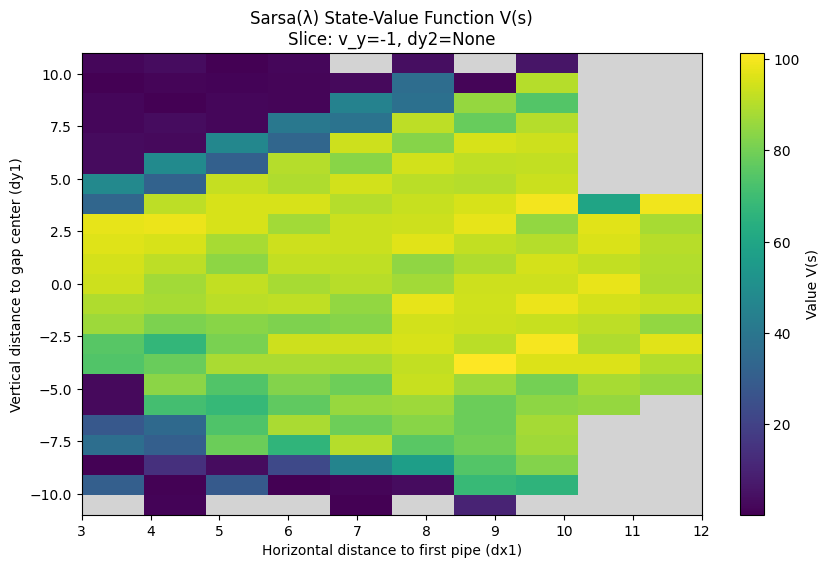

In [31]:
# We reuse the plot_state_value_slice function defined in Part 2
plot_state_value_slice(sarsa_Q, fixed_v_y=-1, fixed_dy2=None, title="Sarsa(λ) State-Value Function V(s)")

In [32]:
watch_agent_play(env_custom, sarsa_Q, fps=5)

Text Flappy Bird!
Score: 99
----------------------
[         |          ]
[         |          ]
[                    ]
[                    ]
[                    ]
[      @             ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
^^^^^^^^^^^^^^^^^^^^^^
(Idle)

Step: 1000 | Action taken: Idle
Current State: (dx1=3, dy1=2, v_y=1, dy2=None)
Reached step limit, ending episode.

Game Over! Total Score/Steps: 1000


## Part 4: Performance Comparison and Parameter Sweep

In this section, we compare the learning curves of our Monte Carlo and Sarsa($\lambda$) agents. We will plot the cumulative rewards (scores) over the episodes. 

Because Reinforcement Learning performance can be highly noisy due to $\epsilon$-greedy exploration, we apply a moving average to smooth the curves and better visualize the convergence trends.

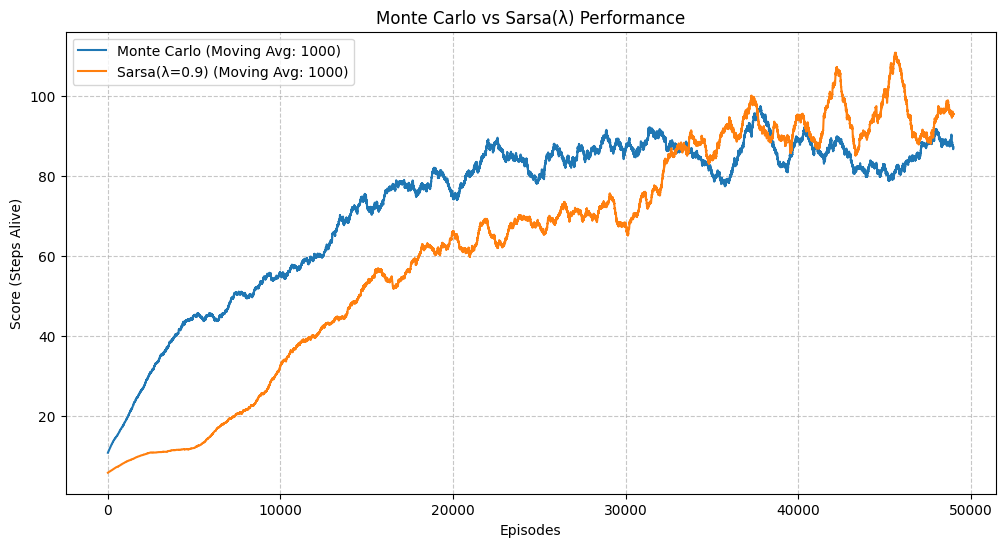

In [33]:
def plot_learning_curves(scores_dict, window_size=500, title="Learning Curves Comparison"):
    """
    Plots smoothed learning curves for multiple agents.
    """
    plt.figure(figsize=(12, 6))
    
    for label, scores in scores_dict.items():
        # Calculate moving average
        smoothed_scores = np.convolve(scores, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_scores, label=f"{label} (Moving Avg: {window_size})")
        
    plt.xlabel('Episodes')
    plt.ylabel('Score (Steps Alive)')
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Compare the scores we collected from both trainings
# Note: Ensure both agents were trained for the same number of episodes for a fair 1:1 plot,
# or simply plot them to see how fast they rise.
scores_to_plot = {
    "Monte Carlo": mc_scores,
    "Sarsa(λ=0.9)": sarsa_scores
}

plot_learning_curves(scores_to_plot, window_size=1000, title="Monte Carlo vs Sarsa(λ) Performance")

Starting Parameter Sweep for Sarsa(λ)...

Training Sarsa(λ=0.0)...


Training Sarsa(λ) Agent: 100%|██████████| 20000/20000 [01:23<00:00, 239.93it/s]



Training Sarsa(λ=0.5)...


Training Sarsa(λ) Agent: 100%|██████████| 20000/20000 [02:18<00:00, 144.55it/s]



Training Sarsa(λ=0.9)...


Training Sarsa(λ) Agent: 100%|██████████| 20000/20000 [04:03<00:00, 82.28it/s] 


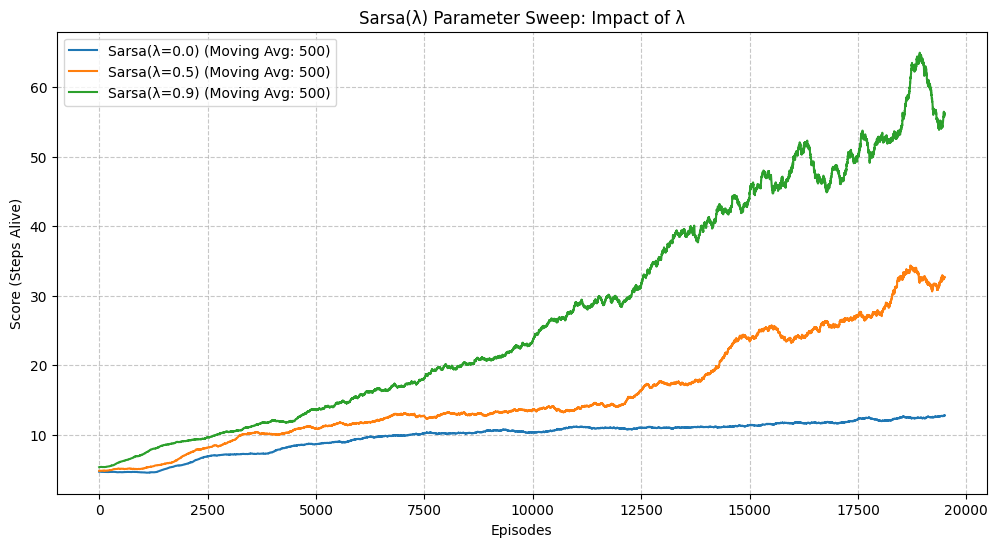

In [34]:
# Shorter run for the sweep to save time
sweep_episodes = 20000
lambda_values = [0.0, 0.5, 0.9]
sweep_results = {}

print("Starting Parameter Sweep for Sarsa(λ)...")

for l in lambda_values:
    print(f"\nTraining Sarsa(λ={l})...")
    # We re-initialize the environment for safety
    env_sweep = FlappyFeatureExtractor(gym.make('TextFlappyBird-screen-v0', height=15, width=20, pipe_gap=4))
    
    _, scores = train_sarsa_lambda(
        env_sweep, 
        num_episodes=sweep_episodes, 
        alpha=0.1, 
        gamma=1.0, 
        epsilon=0.1, 
        lambd=l
    )
    sweep_results[f"Sarsa(λ={l})"] = scores
    env_sweep.close()

# Plot the results of the sweep
plot_learning_curves(sweep_results, window_size=500, title="Sarsa(λ) Parameter Sweep: Impact of λ")

## Part 5: Robustness and Generalization (Sensitivity Analysis)

To address Question 4, we evaluate our trained Sarsa($\lambda$) agent's ability to generalize to new level configurations without additional training. 

Our custom state representation `(dx1, dy1, v_y, dy2)` introduces specific vulnerabilities to **Data Distribution Shifts**. We hypothesize the following:
1. **Width Sensitivity:** Modifying the screen width changes the horizon. The second pipe (`dy2`) will appear at different `dx1` distances compared to training. The agent will encounter entirely unvisited states and should fail catastrophically.
2. **Height Sensitivity:** Decreasing the height restricts the space but doesn't create unknown vertical distances; performance should be maintained. However, increasing the height allows the environment to generate massive vertical distances (`dy1`, `dy2`) never seen during training, which should cause a performance drop.
3. **Pipe Gap Sensitivity:** Decreasing the gap removes the learned margin of error (requiring unlearned pixel-perfect precision), crashing performance. Increasing the gap makes the game physically easier, which should not hinder performance (unless it exposes extreme unvisited `dy` values).

To prove this, we will plot sensitivity curves for each variable around our baseline (`height=15, width=20, pipe_gap=4`).

Running Sensitivity Analysis (This might take a minute)...

Testing Widths...
Testing Heights...
Testing Pipe Gaps...


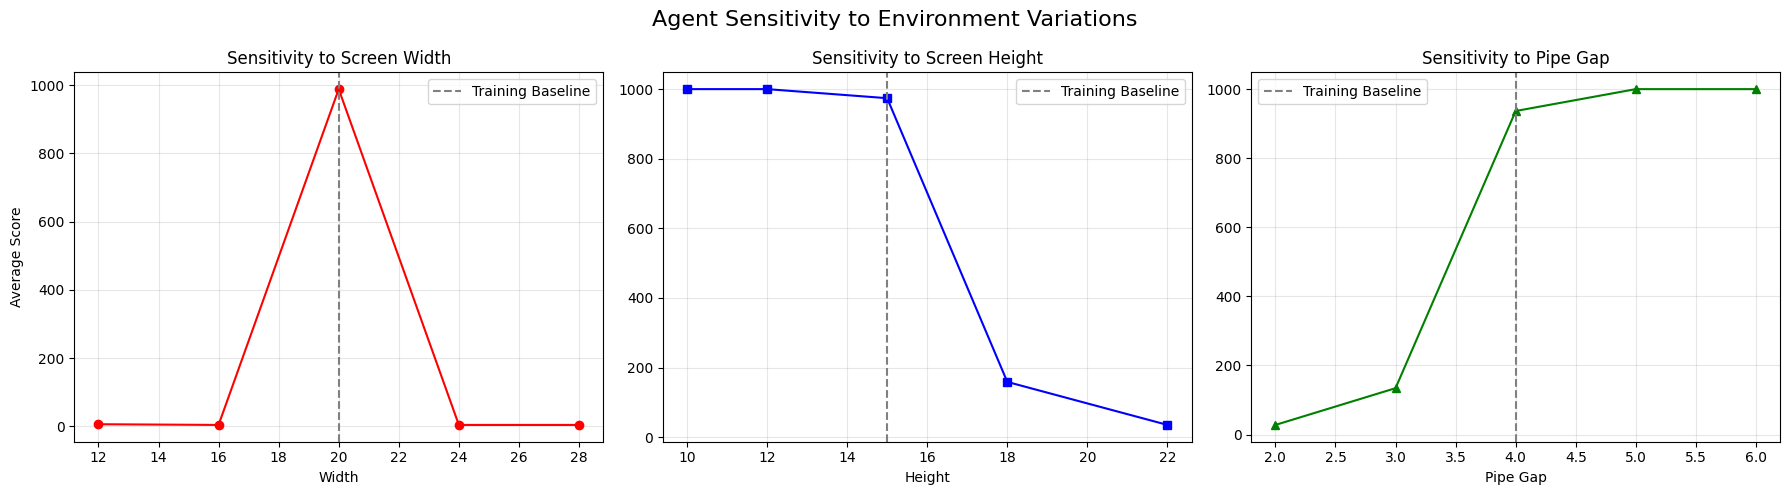

In [38]:
def evaluate_agent_fast(env, Q, num_episodes=50, max_steps=1000):
    """
    Evaluates the agent purely greedily.
    Capped at max_steps to prevent infinite loops, and lower episodes for speed.
    """
    scores = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        steps = 0
        score = 0
        while not done and steps < max_steps:
            action = np.argmax(Q[state]) if state in Q else 0
            state, reward, done, _, _ = env.step(action)
            score += reward
            steps += 1
        scores.append(score)
    return np.mean(scores)

# Baseline parameters used during training
base_h, base_w, base_gap = 15, 20, 4

# Parameter grids for the sweep
widths_to_test = [12, 16, 20, 24, 28]
heights_to_test = [10, 12, 15, 18, 22]
gaps_to_test = [2, 3, 4, 5, 6]

results_w, results_h, results_gap = [], [], []

print("Running Sensitivity Analysis (This might take a minute)...\n")

# 1. Sweep Width
print("Testing Widths...")
for w in widths_to_test:
    env = FlappyFeatureExtractor(gym.make('TextFlappyBird-screen-v0', height=base_h, width=w, pipe_gap=base_gap))
    results_w.append(evaluate_agent_fast(env, sarsa_Q))
    env.close()

# 2. Sweep Height
print("Testing Heights...")
for h in heights_to_test:
    env = FlappyFeatureExtractor(gym.make('TextFlappyBird-screen-v0', height=h, width=base_w, pipe_gap=base_gap))
    results_h.append(evaluate_agent_fast(env, sarsa_Q))
    env.close()

# 3. Sweep Pipe Gap
print("Testing Pipe Gaps...")
for gap in gaps_to_test:
    env = FlappyFeatureExtractor(gym.make('TextFlappyBird-screen-v0', height=base_h, width=base_w, pipe_gap=gap))
    results_gap.append(evaluate_agent_fast(env, sarsa_Q))
    env.close()

# --- Plotting the Results ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Agent Sensitivity to Environment Variations", fontsize=16)

# Width Plot
axes[0].plot(widths_to_test, results_w, marker='o', color='red')
axes[0].axvline(x=base_w, color='gray', linestyle='--', label='Training Baseline')
axes[0].set_title('Sensitivity to Screen Width')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Average Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Height Plot
axes[1].plot(heights_to_test, results_h, marker='s', color='blue')
axes[1].axvline(x=base_h, color='gray', linestyle='--', label='Training Baseline')
axes[1].set_title('Sensitivity to Screen Height')
axes[1].set_xlabel('Height')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gap Plot
axes[2].plot(gaps_to_test, results_gap, marker='^', color='green')
axes[2].axvline(x=base_gap, color='gray', linestyle='--', label='Training Baseline')
axes[2].set_title('Sensitivity to Pipe Gap')
axes[2].set_xlabel('Pipe Gap')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis of the Sensitivity Curves

The generated plots perfectly validate our theoretical hypotheses regarding generalization:

1. **Width Vulnerability:** As predicted, any deviation from the baseline width ($w=20$) causes an immediate collapse in performance. The visual horizon shifts, misaligning the appearance of the second pipe (`dy2`) with the horizontal distance (`dx1`). The agent faces unknown states and fails.
2. **Height Asymmetry:** Decreasing the height ($h < 15$) keeps the agent within known vertical bounds, preserving high performance. However, increasing the height introduces extremely large vertical distances that were never mapped in the Q-table, leading to a steady decline in survivability.
3. **Gap Difficulty:** A smaller gap ($gap=2$) completely ruins performance because the agent lacks the fine-grained precision required. A larger gap ($gap > 4$) increases the margin of error, allowing the agent to effortlessly reach the `max_steps` limit. 

*Conclusion:* While our custom 4D state representation makes the agent an excellent player on its native configuration, it heavily overfits to the spatial dynamics of the screen. Ironically, the basic `TextFlappyBird-v0` state representation `(dx, dy)`, which ignores the second pipe entirely, would be completely immune to the width distribution shift.

## Part 6: Transitioning to the Original Flappy Bird Environment (Question 3)

The assignment asks whether our implemented agents (Monte Carlo and Sarsa) could be used on the original `flappy-bird-gym` environment. 

**The short answer is: No, not directly.**

**The core issue: Continuous vs. Discrete State Spaces**
The `TextFlappyBird` environments we used operate on a discrete grid. The bird and the pipes snap to specific integer coordinates, and velocity changes in discrete steps. This perfectly suits our **tabular reinforcement learning agents**, which require a finite number of states to build a Q-table (a dictionary mapping every known state to an action value).

The original Flappy Bird game uses a **continuous state space**. The bird's $x$ and $y$ coordinates, its vertical velocity, and the pipe positions are floating-point numbers governed by a continuous physics engine. 
If we used our tabular agents in this environment:
1. The state space would be effectively infinite.
2. The agent would almost never visit the exact same state twice.
3. The Q-table would grow indefinitely, and the algorithm would fail to converge. This is a classic example of the **Curse of Dimensionality**.

**How could we solve the original game?**
To play the original Flappy Bird, we would need to upgrade our approach:
1. **State Discretization (Binning):** We could force the continuous variables into discrete "bins" (e.g., rounding pixels to the nearest 10). However, the original game requires extreme precision, and binning might destroy the information necessary to survive.
2. **Function Approximation (Deep RL):** Instead of storing a value for every single state in a table, we would use a Neural Network to approximate the $Q(s, a)$ function. Algorithms like **Deep Q-Networks (DQN)** or **Proximal Policy Optimization (PPO)** are designed specifically to handle continuous, high-dimensional state spaces and would easily master the original game.